,diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Dataset shape: (569, 31)

Class Distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


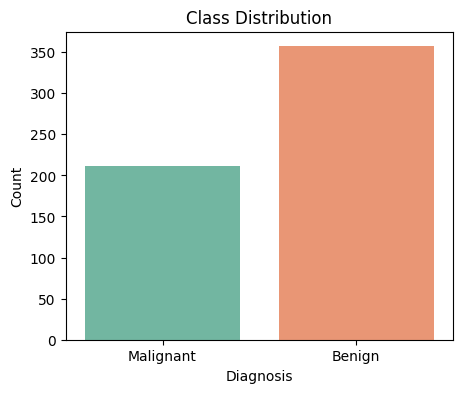

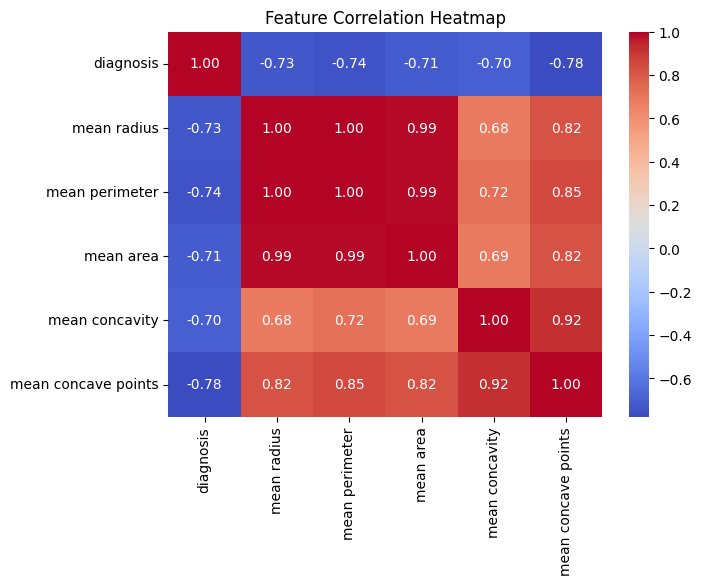

Training size: (455, 5)
Testing size: (114, 5)

Model: KNN
Accuracy: 0.9386
              precision    recall  f1-score   support

   Malignant       0.91      0.93      0.92        43
      Benign       0.96      0.94      0.95        71

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114


Model: Logistic Regression
Accuracy: 0.9211
              precision    recall  f1-score   support

   Malignant       0.90      0.88      0.89        43
      Benign       0.93      0.94      0.94        71

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.92       114
weighted avg       0.92      0.92      0.92       114


Model: Naive Bayes
Accuracy: 0.9561
              precision    recall  f1-score   support

   Malignant       0.97      0.91      0.94        43
      Benign       0.95      0.99      0.97        71

    accuracy            

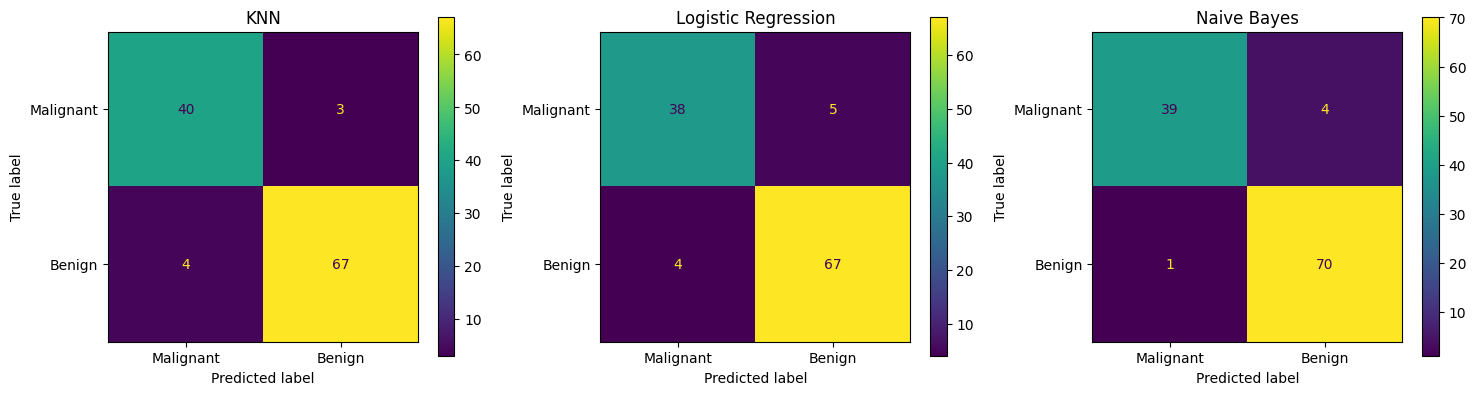


5-Fold Cross Validation Results

KNN:
  Accuracy : 0.9077
  Std Dev  : (+/- 0.0493)
Logistic Regression:
  Accuracy : 0.9099
  Std Dev  : (+/- 0.0378)
Naive Bayes:
  Accuracy : 0.9011
  Std Dev  : (+/- 0.0501)

FINAL MODEL COMPARISON
              Model Accuracy
                KNN   93.86%
Logistic Regression   92.11%
        Naive Bayes   95.61%


In [8]:
# ============================================================
# BREAST CANCER CLASSIFICATION
# Dataset: sklearn built-in (WDBC)
# Models: KNN, Logistic Regression, Naive Bayes
# ============================================================

# IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# ============================================================
# LOAD DATA
# ============================================================
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df.insert(loc=0, column='diagnosis', value=data.target)

display(df.head())
print("Dataset shape:", df.shape)
print("\nClass Distribution:")
print(df['diagnosis'].value_counts().rename({0: 'Malignant', 1: 'Benign'}))

# ============================================================
# EDA
# ============================================================

# Class distribution plot
plt.figure(figsize=(5, 4))
sns.countplot(x='diagnosis', data=df, hue='diagnosis', palette='Set2', legend=False)
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.title('Class Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

# Correlation heatmap
# These 5 features were selected because they show the strongest
# correlation with diagnosis as visible in the heatmap below
selected = ['diagnosis', 'mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points']
plt.figure(figsize=(7, 5))
sns.heatmap(df[selected].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# ============================================================
# FEATURE SELECTION & TRAIN TEST SPLIT
# Features chosen: mean radius, mean perimeter, mean area,
# mean concavity, mean concave points
# Reason: highest correlation with diagnosis from heatmap above
# ============================================================
X = df[['mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points']]
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

# ============================================================
# TRAIN ALL MODELS
# KNN        - classifies based on nearest neighbors
# LR         - finds a linear decision boundary
# Naive Bayes - uses probability based on feature distributions
# ============================================================

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
knn_y_pred = knn.predict(X_test_scaled)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_y_pred = lr.predict(X_test_scaled)

# Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
gnb_y_pred = gnb.predict(X_test_scaled)

# ============================================================
# EVALUATION — ACCURACY + F1 + CLASSIFICATION REPORT
# Using Precision, Recall and F1 because for medical data,
# false negatives (missed cancer) are very costly
# ============================================================
models = {
    'KNN': knn_y_pred,
    'Logistic Regression': lr_y_pred,
    'Naive Bayes': gnb_y_pred
}

for name, pred in models.items():
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_test, pred):.4f}")
    print(classification_report(y_test, pred, target_names=['Malignant', 'Benign']))

# Confusion matrix plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=['Malignant', 'Benign'], ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

# ============================================================
# CROSS VALIDATION
# 5-Fold CV to check if model generalizes well on unseen data
# ============================================================
print("\n5-Fold Cross Validation Results\n")
for name, model in [('KNN', knn), ('Logistic Regression', lr), ('Naive Bayes', gnb)]:
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    print(f"{name}:")
    print(f"  Accuracy : {np.mean(scores):.4f}")
    print(f"  Std Dev  : (+/- {np.std(scores)*2:.4f})")

# ============================================================
# FINAL MODEL COMPARISON
# ============================================================
print("\n" + "="*40)
print("FINAL MODEL COMPARISON")
print("="*40)
results = pd.DataFrame({
    'Model': list(models.keys()),
    'Accuracy': [accuracy_score(y_test, pred) for pred in models.values()]
})
results['Accuracy'] = results['Accuracy'].apply(lambda x: f"{x*100:.2f}%")
print(results.to_string(index=False))